# Perception in the garmi-apartment: find what stands on the floor and put it in the twin

The sibling of `stretch_perception_cram.ipynb`, in the flat that lives in
`assets/garmi-apartment/world.usda`. Same robot, same robokudo pipeline, same four
steps: aim the head, read the RGB-D stream, cluster what is standing on a surface,
add each cluster to the `semantic_digital_twin` world.

**Kernel**: select **CRAM**.

## What is different here, and why

The digital twin for this scene is
`ros2_ws/src/iai_maps/iai_garmi_apartment/mjcf/scene-bodies.xml`, an **MJCF converted
from the very USD Isaac renders**. That one fact changes both ends of the demo.

### The alignment is free

`stretch_perception_cram.ipynb` works in a flat described *twice*, by two independently
authored files that disagree: lining `apartment.urdf` up with `apartmentICRA.usda` took
a measured 180 deg yaw plus a probed x/y/z offset
(`cram_vrb_lab.scenes.apartment.constants`). Here the transform is the **identity** --
the USD `Root/Meshes/Base/Wall` prim and the MJCF `wall_0` body both sit at
(-1.4967, 4.8020, 1.5), and every other body matches the same way. So the USD prim goes
in at the origin and the MJCF root is merged onto `map` unchanged.

### There is no gap to close -- so the twin becomes the answer key

The other notebook's premise was that four objects on the kitchen counter
(`SM_MilkBox`, `SM_CerealBox`, `SM_SmallBowl`, `SM_Cup`) exist in the USD and in **zero**
URDF links: the camera could see them and the twin could not, and closing that gap was
the point.

That premise does not hold in a converted asset. Everything the camera can see is
already in the twin, by construction. Rather than pretend otherwise, this notebook uses
it: after the detections go into the world, **step 5 scores them against the twin's own
bodies**, which are exact ground truth for what Isaac rendered. The other notebook could
not do that at any price.

So read this one as *"does the perception pipeline actually recover the furniture, and
how close does it get?"* rather than *"the twin learns something new"*.

### It looks at the floor, not at a worktop

This apartment has no counter with a group of small objects on it. Every horizontal
surface in it -- the dining table, the kitchen worktop, the nightstand, the bay-window
platform -- is bare, and its only clustered small objects are the eleven books shelved
*inside* `bookshelf_0`, where the shelf above occludes the view from any standing height
and the largest plane in frame is the shelf's back panel rather than a support surface.

So the head is aimed at the **living-room floor**, which gives the pipeline exactly the
geometry it wants: one large dominant plane with well-separated objects standing on it --
the coffee table, the sofa and the floor lamp. The crop and the cluster thresholds move
with that choice; see `FLOOR_CROP` and `FLOOR_CLUSTER_TUNING` in
`cram_vrb_lab.scenes.garmi_apartment.constants`.

## What comes back still has no labels

Unchanged from the other notebook, and worth repeating. The pipeline is geometric: crop
the point cloud, fit the dominant plane, cluster what stands on it, fit an oriented box
to each cluster. That yields *"there are N things on that surface, here is each one's
pose and extent"* and no class names. `torch`/`ultralytics` are not installed in this
venv, so robokudo's learned annotators cannot run. **Nothing here recognises a sofa** --
step 5 matches detections to furniture by *position*, which is a check on the geometry,
not a classification.

## Start the simulation and giskard server

`camera="both"` matters: it is what makes the sim publish `/head_camera/image_raw` *and*
`/head_camera/depth/image_raw`. Without it the detection cell has nothing to read and
will time out.

`scene="garmi_apartment"` is most of the difference: the same two scripts load
`world.usda`, and the giskard server merges this scene's MJCF instead of
`apartment.urdf`.

`spawn_position` is the rest of it, and this scene cannot do without it: the map
origin lies **outside** this flat (it spans x in [-5.3, 2.3], y in [1.2, 8.7]), so the
default spawn at the origin would drop the robot into the void beyond the south wall.
`(0.0, 6.0, 0.05)` puts it in the living room facing `map` +x; the 0.05 m lets the
wheels settle onto the floor rather than start inside it. The giskard server is given
the same value, though for a robot with a base it is the odometry it publishes that
actually tells giskard where it is.

In [ ]:
import sys
from pathlib import Path

REPO = Path.cwd().resolve().parent  # this notebook lives in demos/
sys.path.insert(0, str(REPO))

import os
os.environ["DISPLAY"] = ":0"

from launcher import start_isaac_sim, start_giskard_server, start_rviz, stop

RVIZ_CONFIG = REPO / "demos" / "rviz" /"garmi.rviz"
SCENE = "garmi_apartment"  # with the default robot, the stretch

# In the living room, facing map +x -- the map origin is outside this flat.
SPAWN_POSITION = (0.0, 6.0, 0.05)

rviz_proc = start_rviz(rviz_config=RVIZ_CONFIG)
sim_proc = start_isaac_sim(scene=SCENE, spawn_position=SPAWN_POSITION, camera="both")
giskard_proc = start_giskard_server(scene=SCENE, spawn_position=SPAWN_POSITION)

killed a stale instance of rviz2
starting rviz2, logging to /tmp/rviz.log
starting isaac sim, logging to /tmp/isaac_sim.log
isaac sim ready after 22s
starting giskard server, logging to /tmp/giskard_server.log
giskard server ready after 16s


## Connect and build a CRAM `Context`

Verbatim from `stretch_perception_cram.ipynb` -- none of it depends on which flat the
robot is standing in. The `node` and its spinning `MultiThreadedExecutor` built here are
reused by robokudo later: it needs somewhere to put its camera subscriptions, and a
second executor would only fight this one.

In [2]:
import threading

import nest_asyncio
import rclpy
from rclpy.executors import MultiThreadedExecutor

nest_asyncio.apply()  # CRAM's REAL execution calls GiskardWrapper.execute,
                      # which run_until_completes inside the already-running kernel loop.

from coraplex.datastructures.dataclasses import Context
from coraplex.alternative_motion_mappings.stretch_motion_mapping import (
    StretchMoveToolCenterPoint,
    StretchMoveSim,
    StretchMoveReal,
    StretchClose,
)
from semantic_digital_twin.robots.stretch import Stretch
from semantic_digital_twin.adapters.ros.world_fetcher import fetch_world_from_service
from semantic_digital_twin.adapters.ros.world_synchronizer import WorldSynchronizer

STRETCH_MOTION_MAPPINGS = [
    StretchMoveToolCenterPoint,
    StretchMoveSim,
    StretchMoveReal,
    StretchClose,
]

if not rclpy.ok():
    rclpy.init()
node = rclpy.create_node('cram_garmi_perception_node')
executor = MultiThreadedExecutor()
executor.add_node(node)
threading.Thread(target=executor.spin, daemon=True, name='rclpy-executor').start()

world = fetch_world_from_service(node=node, timeout_seconds=300)
WorldSynchronizer(_world=world, node=node)

robot = world.get_semantic_annotations_by_type(Stretch)
robot = robot[0] if robot else Stretch.from_world(world)

context = Context(
    world=world,
    robot=robot,
    ros_node=node,
    evaluate_conditions=False,
    alternative_motion_mappings=STRETCH_MOTION_MAPPINGS,
)
print('connected, robot:', type(robot).__name__)
print('bodies in the twin:', len(world.bodies))

connected, robot: Stretch
bodies in the twin: 143


## A small run helper

In [3]:
from coraplex.execution_environment import real_robot
from coraplex.plans.factories import sequential, execute_single


def run_plan(plan, collision_avoidance=True):
    """Perform a CRAM plan on the real (sim) robot via giskard."""
    with real_robot(collision_avoidance=collision_avoidance):
        plan.perform()
    print('done')

In [4]:
from coraplex.robot_plans.actions.core.robot_body import SetGripperAction
from semantic_digital_twin.datastructures.definitions import GripperState
from coraplex.robot_plans.actions.core.robot_body import (
    ParkArmsAction,
    MoveTorsoAction,
)
from coraplex.datastructures.enums import Arms
from semantic_digital_twin.datastructures.definitions import TorsoState

run_plan(sequential([
    ParkArmsAction(Arms.LEFT),
    MoveTorsoAction(TorsoState.HIGH),
], context=context))

run_plan(execute_single(SetGripperAction(Arms.LEFT, GripperState.OPEN), context=context))

[INFO] [1785848262.438978082] [cram_garmi_perception_node]: giskard/command Goal #0 accepted
[INFO] [1785848279.858513726] [cram_garmi_perception_node]: giskard/command Goal #0 result received


done


[INFO] [1785848280.246778179] [cram_garmi_perception_node]: giskard/command Goal #0 accepted


done


[INFO] [1785848291.207794475] [cram_garmi_perception_node]: giskard/command Goal #0 result received


In [5]:
from coraplex.robot_plans.actions.core.navigation import NavigateAction
from semantic_digital_twin.spatial_types import Pose, Quaternion, Point3

waypoints = [
    ([0.5, 4.5, 0.0], [0, 0, 0, 1]),
    # ([0.5, 6.5, 0.0], [0, 0, 1, 1]),

    # ([-1.0, 4.5, 0.0], [0, 0, -1, 0]),
    # ([1.8, 5, 0.0], [0, 0, 0, 1]),
    # ([-1.5, 5, 0.0], [0, 0, -1, 0])
]

for _waypoint in waypoints:
    target = Pose(
        Point3.from_iterable(_waypoint[0]),
        Quaternion.from_iterable(_waypoint[1]),
        reference_frame=world.root
    )
    run_plan(execute_single(NavigateAction(target), context=context))

[INFO] [1785848291.618475524] [cram_garmi_perception_node]: giskard/command Goal #0 accepted


done


[INFO] [1785848338.963757146] [cram_garmi_perception_node]: giskard/command Goal #0 result received


## 1. Look at the living-room floor

`LookAtAction` drives `joint_head_pan` / `joint_head_tilt` through giskard's `Pointing`
goal so the robot's default camera -- `camera_color_optical_frame`, marked
`default_camera=True` on the Stretch model -- points at a world position.

`LIVING_ROOM_FLOOR` is the floor 1.3 m in front of the spawn. The robot spawns at
`SPAWN_POSITION` facing `map` +x with the coffee table 0.9 m ahead, the sofa and
the floor lamp a little beyond it to either side, so **no driving is needed** -- the
group is already in frame. If you want to work somewhere else in the flat, drive there
with `NavigateAction` first; the waypoint loop from `stretch_apartment_cram.ipynb`
step 3 still applies.

Like the other notebook, these coordinates only decide **where to point the head**. They
are not fed to the detector.

In [6]:
from coraplex.robot_plans.actions.core.navigation import LookAtAction
from semantic_digital_twin.spatial_types import Pose, Point3

from cram_vrb_lab.scenes.garmi_apartment.constants import (
    FLOOR_CLUSTER_TUNING,
    FLOOR_CROP,
    FURNITURE_IN_VIEW,
    LIVING_ROOM_FLOOR,
)


In [7]:

# print('robot spawned at', SPAWN_POSITION, '-> looking at', LIVING_ROOM_FLOOR)

# run_plan(execute_single(
#     LookAtAction(Pose(Point3.from_iterable((-1.0, 7.5, 0.5)), reference_frame=world.root)),
#     context=context,
# ))


In [8]:

from cram_vrb_lab.perception.twin_objects import camera_pose_in_map
import numpy as np

print('camera in map:\n', np.round(camera_pose_in_map(world), 3))

camera in map:
 [[-0.     0.047  0.999  0.546]
 [ 0.     0.999 -0.047  4.5  ]
 [-1.     0.    -0.     1.322]
 [ 0.     0.     0.     1.   ]]


## 2. What the camera actually sees

Worth looking at before trusting any detector. If the furniture is not in frame here,
nothing downstream can work, and you would otherwise be debugging the pipeline for a
problem that is really the head angle.

Decoded with `np.frombuffer` rather than `cv_bridge`: the system `cv_bridge` is compiled
against NumPy 1.x, this venv has NumPy 2.x, and calling it **segfaults the kernel**. The
two encodings are trivial to unpack by hand -- `rgb8` is HxWx3 uint8, `32FC1` is HxW
float32 in metres with `NaN` where the ray hit nothing.

A dark image here means the fill lights are not doing their job. This apartment has a
`Base/Ceiling` mesh at z = 2.9 that shuts out the scene's own outdoor `DomeLight`, which
is why `isaac_scene.INDOOR_LIGHT_POSITIONS` puts four sphere lights just under it.

rgb   (360, 640, 3) rgb8  frame=camera_color_optical_frame
depth (360, 640) 32FC1  valid 78%  range 0.47..1.91 m


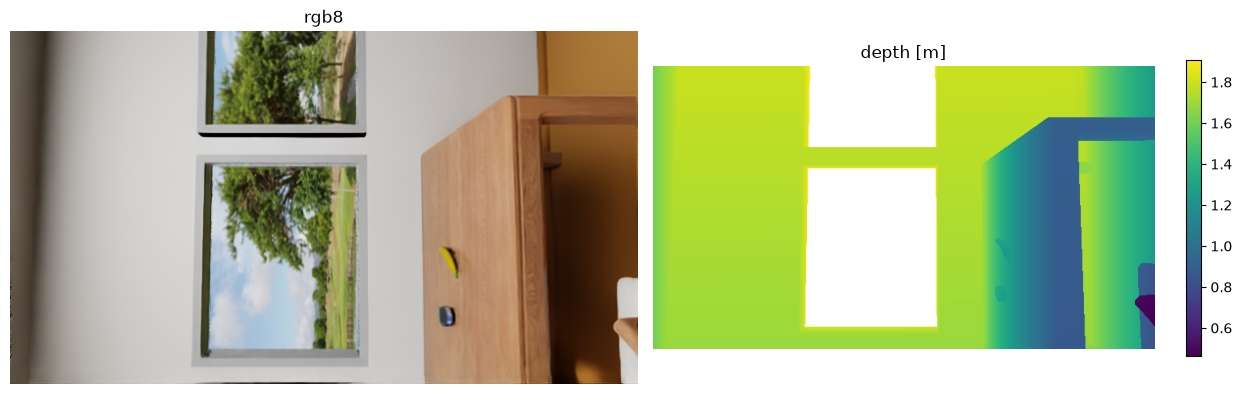

In [9]:
import matplotlib.pyplot as plt
%matplotlib inline

from sensor_msgs.msg import Image

from cram_vrb_lab.robots.stretch.joints import DEPTH_IMAGE_TOPIC, RGB_IMAGE_TOPIC


def grab(topic, timeout=15.0):
    """Return the next message on `topic`, using the executor already spinning."""
    import time
    box = {}
    sub = node.create_subscription(Image, topic, lambda m: box.setdefault('m', m), 1)
    try:
        deadline = time.time() + timeout
        while 'm' not in box and time.time() < deadline:
            time.sleep(0.05)
    finally:
        node.destroy_subscription(sub)
    if 'm' not in box:
        raise TimeoutError(f'nothing published on {topic} within {timeout}s '
                           '-- was the sim started with camera="both"?')
    return box['m']


rgb_msg, depth_msg_ = grab(RGB_IMAGE_TOPIC), grab(DEPTH_IMAGE_TOPIC)
rgb = np.frombuffer(rgb_msg.data, np.uint8).reshape(rgb_msg.height, rgb_msg.width, 3)
depth = np.frombuffer(depth_msg_.data, np.float32).reshape(depth_msg_.height,
                                                           depth_msg_.width)

print(f'rgb   {rgb.shape} {rgb_msg.encoding}  frame={rgb_msg.header.frame_id}')
print(f'depth {depth.shape} {depth_msg_.encoding}  '
      f'valid {np.isfinite(depth).mean():.0%}  '
      f'range {np.nanmin(depth):.2f}..{np.nanmax(depth[np.isfinite(depth)]):.2f} m')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].imshow(rgb); axes[0].set_title('rgb8'); axes[0].axis('off')
im = axes[1].imshow(np.where(np.isfinite(depth), depth, np.nan), cmap='viridis')
axes[1].set_title('depth [m]'); axes[1].axis('off')
fig.colorbar(im, ax=axes[1], shrink=0.8)
plt.tight_layout()
plt.show()

## 3. Detect

robokudo's geometric analysis engine, ticked in-process against the topics above. The
camera plumbing is shared with the other notebook and explained in
`cram_vrb_lab/perception/pipeline.py`: the stock `"kinect"` config is *overridden* rather
than a new one registered (the descriptor factory picks the interface class from a dict
keyed by the same name, so a new name would resolve to no interface at all), and
`StretchHeadCameraInterface` converts Isaac's metres to the millimetres robokudo's cloud
builder assumes.

What is scene-specific is the two dicts passed to `build_pipeline`:

- **`FLOOR_CROP`** bounds the depth to 0.4-4.0 m so the far walls and the rooms beyond
  the living room never reach the plane fit, and stays deliberately wide in x/y: with the
  optical axis pointed at the floor, the floor sweeps across most of the frame and a
  tight lateral crop would clip the objects standing on it. The crop is in the **camera
  optical frame** (+x right, +y down, +z forward), not in `map`.
- **`FLOOR_CLUSTER_TUNING`** raises the thresholds, which is the opposite of what the
  counter demo needed. There, objects 2.4 m away covered ~12x38 px and robokudo's stock
  `min_cluster_count` of 1000 rejected every one of them. Here a sofa 1.5 m away is
  thousands of points and the risk runs the other way -- leftovers of a large floor plane
  clustering into phantom objects.

On this scene the defaults return **three or four** clusters -- the coffee table, the sofa,
usually a thin slab that is the window wall, and often the floor lamp's stem. Step 5 shows
which is which and how much the count moves between runs.

This cell is re-runnable: it rebuilds the pipeline node each time, for the reason in the
comment. Look somewhere else with step 1 and run it again.

If it finds nothing at all, the usual cause is the plane fit choosing a wall rather than
the floor; tighten `max_z` first.

In [10]:
from cram_vrb_lab.perception import pipeline as rk

# Built once and reused: constructing the descriptor spins up robokudo's own camera
# node and its subscriptions, and a second one would just duplicate them.
descriptor = rk.camera_descriptor()

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [11]:
# A FRESH pipeline node per detect(), and a DEDICATED one -- never the notebook's.
#
# Dedicated, because robokudo's tick helper builds its own executor and calls
# add_node(), which in rclpy detaches the node from the executor already spinning
# it, then removes it again on the way out. Hand it `node` and the
# WorldSynchronizer and every giskard client would go quiet for the rest of the
# session.
#
# Fresh, because a node can only be handed to detect() ONCE: robokudo's
# `grow_tree` calls `py_trees_ros.trees.BehaviourTree.setup`, which declares the
# ROS parameter `default_snapshot_stream` on it, and the second call raises
# `ParameterAlreadyDeclaredException: default_snapshot_stream`. Rebuilding the node
# here is what makes this cell re-runnable -- look somewhere else, run it again.
if 'rk_node' in globals():
    rk_node.destroy_node()
rk_node = rk.make_pipeline_node()

# A fresh pipeline too: py_trees keeps blackboard state on the object.
pipeline = rk.build_pipeline(descriptor, crop=FLOOR_CROP, tuning=FLOOR_CLUSTER_TUNING)
detections = rk.detect(rk_node, descriptor, pipeline=pipeline)

print(f'{len(detections)} cluster(s), poses in camera_color_optical_frame:')
for i, d in enumerate(detections):
    print(f'  [{i}] pos {np.round(d.position, 3)}  '
          f'extent {np.round(d.extents, 3)}  volume {d.volume * 1e3:.2f} L')

{-} StretchHeadCameraPipeline
    --> ClearAnnotatorOutputs
    --> CollectionReader
    --> ImagePreprocessor
    --> PointcloudCropAnnotator
    --> PlaneAnnotator
    --> PointCloudClusterExtractor
    --> ClusterPoseBBAnnotator

5 cluster(s), poses in camera_color_optical_frame:
  [0] pos [-1.679 -0.035  1.641]  extent [2.023e+00 1.630e-01 1.000e-03]  volume 0.40 L
  [1] pos [ 1.32  -0.761  1.508]  extent [0.708 0.31  0.001]  volume 0.32 L
  [2] pos [0.538 0.308 1.302]  extent [1.296 0.8   0.052]  volume 54.32 L
  [3] pos [ 0.854 -0.281  0.958]  extent [0.047 0.    0.343]  volume 0.00 L
  [4] pos [1.27  0.22  1.471]  extent [1.442 0.468 0.103]  volume 69.40 L


## 4. Put them in the twin

Each detection becomes a box body of the detected size, fixed to the world root at the
detected pose, carrying the `perceived` prefix so it is obvious which boxes came from
the camera and which from the MJCF.

The camera->map transform comes from the twin's own forward kinematics, not from tf.
There is no tf listener anywhere in this repo, and giskard stops publishing the fixed
camera frames while it executes a goal -- which is exactly why the sim latches them
separately. `world.compute_forward_kinematics_np` reads the same joint state giskard is
controlling, so it cannot go stale between the look and the lookup.

The world is broadcast to the giskard server over `/world_sync`, so these bodies land in
giskard's collision world too. Re-running this cell replaces the previous detections
rather than stacking a second set on top.

Note what this means *here*, though: the twin already had the furniture, so these boxes
are **redundant copies** of bodies that exist, not new knowledge. That is the honest
consequence of a converted asset, and it is what step 5 measures.

In [12]:
from cram_vrb_lab.perception.twin_objects import add_detections, DETECTION_PREFIX

bodies = add_detections(world, detections)

print(f'{len(bodies)} body(ies) added to the twin:')
for body in bodies:
    position = np.asarray(body.global_pose.to_np())[:3, 3].ravel()
    print(f'  {body.name.name:16s} map {np.round(position, 3)}')

print(f'\nbodies now carrying the {DETECTION_PREFIX!r} prefix:',
      len([b for b in world.bodies if b.name.prefix == DETECTION_PREFIX]))

5 body(ies) added to the twin:
  perceived_0      map [2.184 4.389 3.001]
  perceived_1      map [2.017e+00 3.670e+00 2.000e-03]
  perceived_2      map [1.861 4.748 0.783]
  perceived_3      map [1.49  4.176 0.468]
  perceived_4      map [2.026 4.652 0.052]

bodies now carrying the 'perceived' prefix: 5


/home/jovyan/cram-vrb-lab/cognitive_robot_abstract_machine/.venv/lib/python3.12/site-packages/trimesh/triangles.py:302: RuntimeWarning: invalid value encountered in divide
  center_mass = integrated[1:4] / volume


## 5. Score the detections against the twin's ground truth

The step the other notebook cannot have. Because `scene-bodies.xml` was converted from
the USD Isaac renders, the MJCF bodies are not *a* model of the scene -- they are the
scene, at the same coordinates. So the twin holds an exact answer key for what the camera
was looking at, and each detection can be matched to the nearest piece of furniture.

Read the numbers with two caveats, both real:

- **Horizontal distance only.** A detection's centre is the middle of the oriented box
  fitted to the *visible* points; an MJCF body's origin is wherever the exporter put it,
  which for a sofa is mid-height and for a lamp is up the stem. Those conventions differ
  in z by design, so comparing z would measure the convention rather than the perception.
- **This is a sanity check, not a benchmark.** Matching is nearest-neighbour by position,
  the furniture is metres apart, and a self-occluded object is only ever partly visible,
  so a residual of some tens of centimetres is the expected outcome and not an error. A
  match landing metres away, or an expected object with no detection near it, is the
  signal worth chasing.

### What a good run looks like -- and how much it moves

Measured over a dozen runs of this scene with the defaults above, so you have something to
compare against. **The cluster count is not deterministic**; expect 3 or 4:

| ground truth | typical detection | dxy | seen in |
|---|---|---|---|
| `coffee_table_0` | 0.995 x 0.60 x 0.036 m slab | **0.002 m**, every run | 12/12 |
| `sofa_0` | ~1.5 x 0.7 x 0.4 m block | **0.37 - 0.53 m** | 12/12 |
| `floor_lamp_0` | 0.016 x 0.008 x 0.8 m needle | **0.095 m** when found | 8/12 |
| -- (window wall) | ~1.1 x 0.06 x 0.80 m slab | n/a, matches nothing | most runs |

The spread across those rows is the whole lesson, and each row fails differently:

- The **coffee table** is a compact slab seen nearly whole, so its fitted box lands on the
  MJCF body to 2 mm, run after run. That is the anchor: if this one drifts, something is
  actually wrong.
- The **sofa** is always found and never precise. It sits at the edge of frame with only
  its near face and one arm visible, so the box fitted to those points is centred on the
  visible part, not on the whole piece of furniture. Half a metre is the honest answer to
  "where is the middle of a thing you can only half see".
- The **floor lamp** is recovered as its *stem* -- all there is to see of a lamp at this
  range -- and lands within 0.095 m whenever it appears. But a needle that thin sits close
  to `min_cluster_count`, so in about a third of runs it falls below the threshold and
  vanishes entirely. Lower `min_cluster_count` to keep it, at the price of more floor
  leftovers surviving as phantom objects.
- The **window wall** at x = 2.34 usually comes back as a thin slab matching no furniture,
  which is a correct answer to the question actually asked: a wall does stand on the floor
  plane. Cropping it out means pulling `max_z` in past the lamp at 2.1 m depth and losing
  the lamp too, so it is left in and reported instead.

The variation comes from the head: `LookAtAction` converges to a slightly different
pan/tilt each time (a degree or two), which changes which points survive the crop. Runs
where the sofa and the wall merge into one ~2.2 x 0.95 x 0.8 m blob happen, and are the
clearest sign of it. This is what a geometric pipeline on a real depth stream does -- the
second table below prints every detection's extents precisely so a thin slab, a needle and
a piece of furniture can be told apart by shape rather than taken on trust.

In [13]:
def body_position_in_map(name):
    body = world.get_body_by_name(name)
    return np.asarray(body.global_pose.to_np())[:3, 3].ravel()


detected_positions = [
    np.asarray(b.global_pose.to_np())[:3, 3].ravel() for b in bodies
]

print(f'{len(detected_positions)} detection(s) vs {len(FURNITURE_IN_VIEW)} '
      'expected piece(s) of furniture\n')
print(f'{"ground truth":16s} {"map (x, y)":>18s}  {"nearest detection":>18s}  {"dxy [m]":>8s}')
for name in FURNITURE_IN_VIEW:
    truth = body_position_in_map(name)
    if not detected_positions:
        print(f'{name:16s} {np.round(truth[:2], 3)!s:>18s}  {"-- none --":>18s}  {"":>8s}')
        continue
    distances = [np.linalg.norm(truth[:2] - found[:2]) for found in detected_positions]
    best = int(np.argmin(distances))
    print(f'{name:16s} {np.round(truth[:2], 3)!s:>18s}  '
          f'{np.round(detected_positions[best][:2], 3)!s:>18s}  {distances[best]:8.3f}')


# The other direction. Every detection, with the extents that say what it is: a
# compact slab is furniture, a thin tall one is the wall or a lamp stem. Printed
# unconditionally rather than only for detections far from the answer key -- a
# distance threshold cannot separate "the wall" from "a partly hidden sofa",
# because in this scene both land about half a metre from a known body.
print(f'\n{"detection":12s} {"map (x, y)":>18s}  {"extents (m)":>22s}  '
      f'{"nearest truth":16s} {"dxy [m]":>8s}')
for index, (body, detection) in enumerate(zip(bodies, detections)):
    found = np.asarray(body.global_pose.to_np())[:3, 3].ravel()
    distances = {name: np.linalg.norm(body_position_in_map(name)[:2] - found[:2])
                 for name in FURNITURE_IN_VIEW}
    nearest = min(distances, key=distances.get)
    print(f'{body.name.name:12s} {np.round(found[:2], 3)!s:>18s}  '
          f'{np.round(detection.extents, 3)!s:>22s}  '
          f'{nearest:16s} {distances[nearest]:8.3f}')

5 detection(s) vs 3 expected piece(s) of furniture

ground truth             map (x, y)   nearest detection   dxy [m]
coffee_table_0        [0.626 2.709]       [2.017 3.67 ]     1.691
sofa_0                [1.166 2.099]       [2.017 3.67 ]     1.787
floor_lamp_0          [1.781 3.236]       [2.017 3.67 ]     0.494

detection            map (x, y)             extents (m)  nearest truth     dxy [m]
perceived_0       [2.184 4.389]  [2.023e+00 1.630e-01 1.000e-03]  floor_lamp_0        1.222
perceived_1       [2.017 3.67 ]     [0.708 0.31  0.001]  floor_lamp_0        0.494
perceived_2       [1.861 4.748]     [1.296 0.8   0.052]  floor_lamp_0        1.514
perceived_3       [1.49  4.176]     [0.047 0.    0.343]  floor_lamp_0        0.983
perceived_4       [2.026 4.652]     [1.442 0.468 0.103]  floor_lamp_0        1.437


They should now be visible in RViz as translucent boxes sitting on top of the furniture
they were fitted to -- which, in this scene, is the clearest way to see how well the
pipeline did. Because the twin is what CRAM plans against, a `NavigateAction` or a reach
would treat them as obstacles just like the MJCF furniture.

What this still does *not* do is tell you which box is the sofa. Step 5 matched by
position against an answer key; a pipeline that had to *name* the objects would need a
classifier this venv has no weights for. That is the honest limit of a geometric pipeline,
and it does not change just because the twin happens to know the answer.

## Shutdown

In [ ]:
# stop()  # stops the isaac sim + giskard server + rviz started above

stopped isaac sim + giskard server + rviz


: 